# 3D toric code — vertical line at $h_x=0$: $O_{FM}$ + Rényi-2 transition

Locates the 2nd-order topological$\to$trivial transition (QMC $h_z^c\!\approx\!0.197$)
from two independent local order parameters, extrapolated to $L\to\infty$.

* **$O_{FM}$** — Fredenhagen–Marcu string ratio on a **fixed $R=1$ loop** (perimeter-4
  plaquette), electric sector, `results/phase_hx0.0_bulkR1/`.
* **$S_2$** — Rényi-2 entropy of the central 4-qubit plaquette, `results/phase_hx0.0_s2plaq/`.

Both are fit with a **symmetric tanh** baseline and an **asymmetric Richards** (5-param
generalized logistic) curve; the inflection is the pseudo-critical $h_z(L)$. Per-point
errors are inflated by the **PDG scale-factor method** ($s=\sqrt{\chi^2/\nu}$) to absorb
seed-to-seed NQS training scatter before the finite-size extrapolation
$h_z(L)=h_z^\infty + b\,(1/L)^x$.

Sections: **1** config · **2** data library · **3** curves + derivatives ·
**4** fit models · **5** per-$L$ fits · **6** honest errors · **7** finite-size extrapolation.

In [12]:
# ====================== 1 · CONFIG — the one cell to edit ======================
import json, glob, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

ROOT   = "/Users/sanzhar123/Desktop/Approximate-Symmetries-TC-main/results"
FM_DIR = f"{ROOT}/phase_hx0.0_bulkR1"      # O_FM, fixed R=1 loop  (fm_L*.json)
S2_DIR = f"{ROOT}/phase_hx0.0_s2plaq"      # Renyi-2 central plaquette (s2_L*.json)
FIELD  = "hz"                              # swept field label (this line: h_z at h_x=0)

# ---- RANGE KNOB: only points with H_WINDOW[0] <= h <= H_WINDOW[1] enter the fits ----
H_WINDOW = (0.10, 0.40)                     # e.g. tighten to (0.20, 0.35) around the crossing
EXCLUDE  = {}                               # {(obs, L): [h, ...]} drop specific bad points
#           obs in {"O_FM", "S2"}

# ---- fits ----
FORMS   = ("tanh", "richards")              # baseline first, asymmetric second
N_BOOT  = 500                              # bootstrap resamples for honest h_c(L) errors

# ---- finite-size scaling:  h_c(L) = h_c(inf) + b*(1/L)**x ----
FSS_LS    = None                            # subset of L, e.g. [5, 6, 7]; None = all
FSS_FIX_X = None                            # pin x (e.g. 2.0 = 1/nu_4DIsing); None = fit x free
X_BATTERY = (1.0, 1.50, 2.0)                # exponents swept for the systematic spread

H_C_QMC = 0.197                             # thermodynamic-limit reference (QMC, hx=0)
rng = np.random.default_rng(0)
print(f"field = {FIELD}   window = {H_WINDOW}   forms = {FORMS}   N_BOOT = {N_BOOT}")

field = hz   window = (0.1, 0.4)   forms = ('tanh', 'richards')   N_BOOT = 500


## 2 · Data library

Every point from both campaigns, loaded into a single nested dict `DATA[obs][L]` with
`h`, `y`, `ye` arrays (`raw` keeps the full JSON record). Query it freely in later cells —
e.g. `DATA["O_FM"][6]["y"]` or `points("S2", 7)`.

In [13]:
# ====================== 2 · DATA LIBRARY ======================
def _load(directory, val_key, err_key):
    recs = {}
    for jp in sorted(glob.glob(os.path.join(directory, "*.json"))):
        d = json.load(open(jp))
        recs[int(d["L"])] = dict(
            h=np.array(d["field"], float),
            y=np.array(d[val_key], float),
            ye=np.array(d.get(err_key, np.zeros(len(d["field"]))), float),
            raw=d)
    if not recs:
        raise SystemExit(f"no *.json in {directory}")
    return recs

DATA = {"O_FM": _load(FM_DIR, "O",  "Oe"),
        "S2":   _load(S2_DIR, "S2", "S2e")}
LABEL = {"O_FM": r"$O_{FM}$  (R=1)", "S2": r"$S_2$  (central plaquette)"}

def window_mask(h, obs, L):
    keep = (h >= H_WINDOW[0]-1e-9) & (h <= H_WINDOW[1]+1e-9)
    for hx in EXCLUDE.get((obs, L), []):
        keep &= ~np.isclose(h, hx, atol=1e-6)
    return keep

def points(obs, L, windowed=False):
    """(h, y, ye) for one (obs, L); windowed=True applies H_WINDOW + EXCLUDE."""
    d = DATA[obs][L]
    if not windowed:
        return d["h"], d["y"], d["ye"]
    m = window_mask(d["h"], obs, L)
    return d["h"][m], d["y"][m], d["ye"][m]

for obs in DATA:
    Ls = sorted(DATA[obs])
    print(f"[{obs}]  L = {Ls}")
    for L in Ls:
        h, y, ye = points(obs, L)
        hw, *_ = points(obs, L, windowed=True)
        print(f"    L={L}: {len(h):2d} pts (kept {len(hw):2d} in window)  "
              f"{FIELD} in [{h.min():.3g}, {h.max():.3g}]")

[O_FM]  L = [4, 5, 6, 7]
    L=4: 13 pts (kept 13 in window)  hz in [0.1, 0.4]
    L=5: 13 pts (kept 13 in window)  hz in [0.1, 0.4]
    L=6: 13 pts (kept 13 in window)  hz in [0.1, 0.4]
    L=7: 13 pts (kept 13 in window)  hz in [0.1, 0.4]
[S2]  L = [4, 5, 6, 7]
    L=4: 13 pts (kept 13 in window)  hz in [0.1, 0.4]
    L=5: 13 pts (kept 13 in window)  hz in [0.1, 0.4]
    L=6: 13 pts (kept 13 in window)  hz in [0.1, 0.4]
    L=7: 13 pts (kept 13 in window)  hz in [0.1, 0.4]


## 3 · Order parameters and their derivatives

Top row: raw $O_{FM}(h)$ and $S_2(h)$ for every $L$ (shaded band = fit window).
Bottom row: finite-difference derivatives — the peak is a model-free estimate of the
pseudo-critical field.

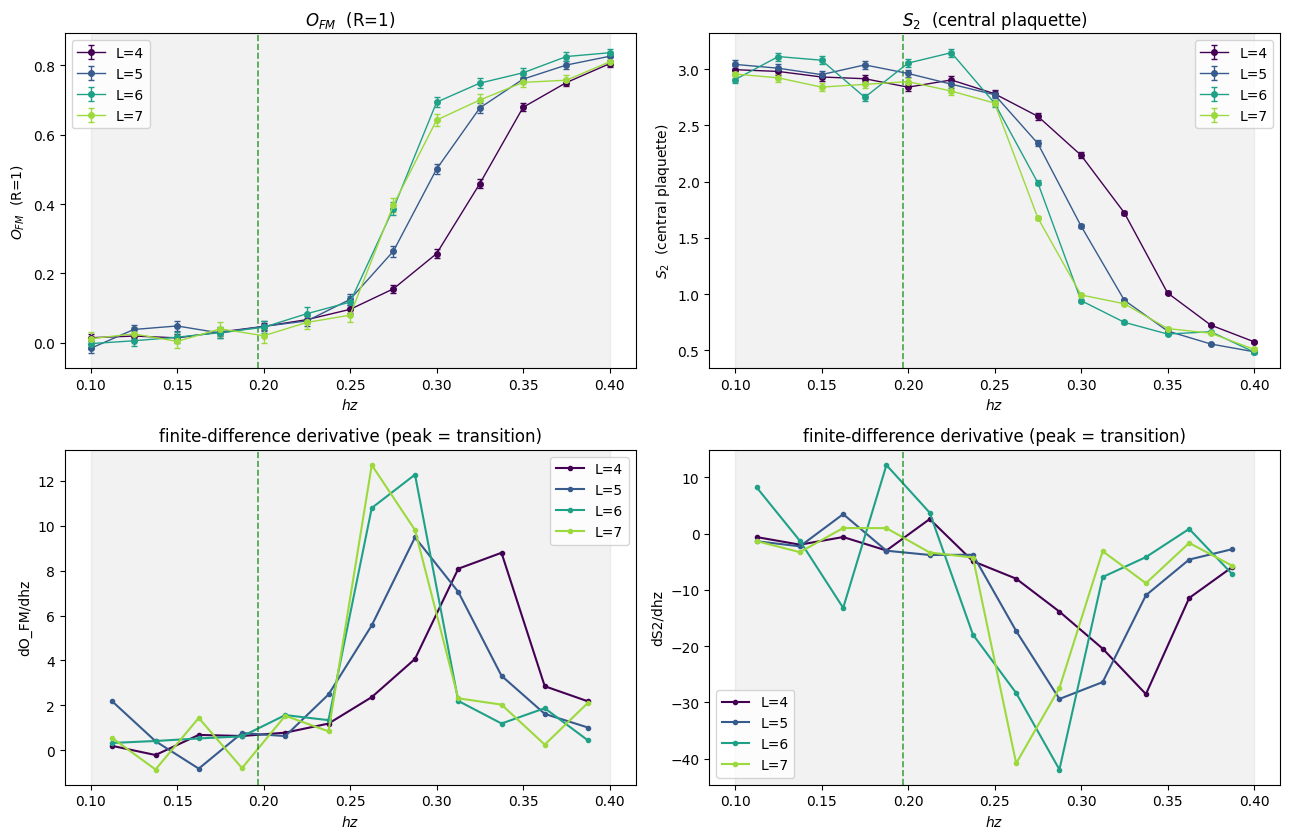

In [14]:
# ====================== 3 · CURVES + DERIVATIVES ======================
fig, ax = plt.subplots(2, 2, figsize=(13, 8.5))
obs_list = ("O_FM", "S2")
for j, obs in enumerate(obs_list):
    Ls = sorted(DATA[obs])
    colors = plt.cm.viridis(np.linspace(0, 0.85, len(Ls)))
    for L, c in zip(Ls, colors):
        h, y, ye = points(obs, L)
        ax[0, j].errorbar(h, y, yerr=ye, fmt="o-", ms=4, lw=1, capsize=2,
                          color=c, label=f"L={L}")
        hm = 0.5*(h[1:] + h[:-1]); d = np.diff(y)/np.diff(h)
        ax[1, j].plot(hm, d, "o-", ms=3, color=c, label=f"L={L}")
    for row in (0, 1):
        ax[row, j].axvspan(*H_WINDOW, color="k", alpha=0.05)
        ax[row, j].axvline(H_C_QMC, ls="--", color="green", lw=1.2, alpha=0.7)
    ax[0, j].set(xlabel=f"${FIELD}$", ylabel=LABEL[obs], title=LABEL[obs]); ax[0, j].legend()
    ax[1, j].set(xlabel=f"${FIELD}$", ylabel=f"d{obs}/d{FIELD}",
                 title=f"finite-difference derivative (peak = transition)"); ax[1, j].legend()
plt.tight_layout(); plt.show()

## 4 · Fit models

**Symmetric tanh** (4 params) — $O(h)=A+B\tanh\!\big((h-h_c)/w\big)$; $h_c$ is the inflection
directly. Robust, few parameters, but forces point-symmetry about $h_c$.

**Richards / generalized logistic** (5 params) —
$O(h)=A+(K-A)\big[1+e^{-(h-h_0)/w}\big]^{-\nu}$, $\nu>0$ tunes asymmetry ($\nu=1\Rightarrow$
logistic). With $\nu\neq1$ the inflection is **not** $h_0$:
$$h_c = h_0 + w\ln\nu ,$$
which we evaluate exactly (and re-evaluate on every bootstrap resample — the honest way to
propagate its error).

In [15]:
# ====================== 4 · FIT MODELS ======================
def richards(h, A, K, h0, w, nu):
    z = np.clip(-(h - h0)/w, -700, 700)        # guard exp overflow on the plateaus
    return A + (K - A) / (1.0 + np.exp(z))**nu

def tanh_model(h, A, B, hc, w):
    return A + B*np.tanh((h - hc)/w)

MODELS = {"richards": richards, "tanh": tanh_model}
NPAR   = {"richards": 5,        "tanh": 4}

def inflection(form, p):
    """Pseudo-critical field = inflection of the fitted curve."""
    if form == "richards":
        A, K, h0, w, nu = p
        return h0 + w*np.log(nu)               # exact inflection of the Richards curve
    A, B, hc, w = p
    return hc

def _p0_bounds(form, h, y):
    lo, hi = float(h.min()), float(h.max())
    hmid, span = 0.5*(lo+hi), (hi-lo) or 1.0
    yl, yr = float(y[0]), float(y[-1])
    if form == "richards":
        # A, K are the left/right plateaus (they carry the rise/fall direction); w>0, nu>0
        p0 = [yl, yr, hmid, 0.05*span, 1.0]
        bnds = ([-np.inf, -np.inf, lo-span, 1e-4, 1e-3],
                [ np.inf,  np.inf, hi+span, span,  50.0])
    else:
        p0 = [0.5*(yl+yr), 0.5*(yr-yl), hmid, 0.05*span]
        bnds = ([-np.inf, -np.inf, lo-span, 1e-4],
                [ np.inf,  np.inf, hi+span, span])
    return p0, bnds

def fit_curve(h, y, ye, form, escale=1.0):
    """Fit one windowed curve; return popt, chi2/dof and the inflection h_c."""
    f = MODELS[form]
    e = ye*escale
    use_w = np.all(np.isfinite(e)) and np.all(e > 0)
    kw = dict(sigma=e, absolute_sigma=True) if use_w else {}
    p0, bnds = _p0_bounds(form, h, y)
    popt, pcov = curve_fit(f, h, y, p0=p0, bounds=bnds, maxfev=80000, **kw)
    resid = y - f(h, *popt)
    chi2 = np.sum((resid/e)**2) if use_w else np.sum(resid**2)
    dof = max(1, len(h) - NPAR[form])
    return dict(popt=popt, pcov=pcov, chi2dof=chi2/dof,
                h_c=float(inflection(form, popt)), weighted=use_w)

## 5 · Per-$L$ fits

Both forms fit to the windowed data for every $L$. The dashed vertical is the inflection
$h_c(L)$; the printed $\chi^2/\nu$ is the input to the scale-factor inflation in §6 — values
$\gg1$ signal that neighbouring points miss any smooth curve by many of their own error bars
(the training-scatter symptom).


[O_FM / tanh]   L      h_c  chi2/dof    width
     4   0.3202       2.9   0.0514
     5   0.2925       1.7   0.0443
     6   0.2768       2.9   0.0311
     7   0.2768       2.9   0.0297

[S2 / tanh]   L      h_c  chi2/dof    width
     4   0.3224       5.6   0.0456
     5   0.2952       2.6   0.0412
     6   0.2782      49.0   0.0272
     7   0.2737      54.3   0.0395

[O_FM / richards]   L      h_c  chi2/dof    width  nu
     4   0.3308       1.2   0.0138  0.33
     5   0.2924       1.9   0.0223  1.01
     6   0.2776       3.3   0.0149  0.88
     7   0.2685       2.2   0.0210  50.00

[S2 / richards]   L      h_c  chi2/dof    width  nu
     4   0.3300       3.9   0.0164  0.46
     5   0.2936       2.8   0.0217  1.24
     6   0.2728      52.1   0.0174  3.68
     7   0.2648      43.5   0.0257  50.00


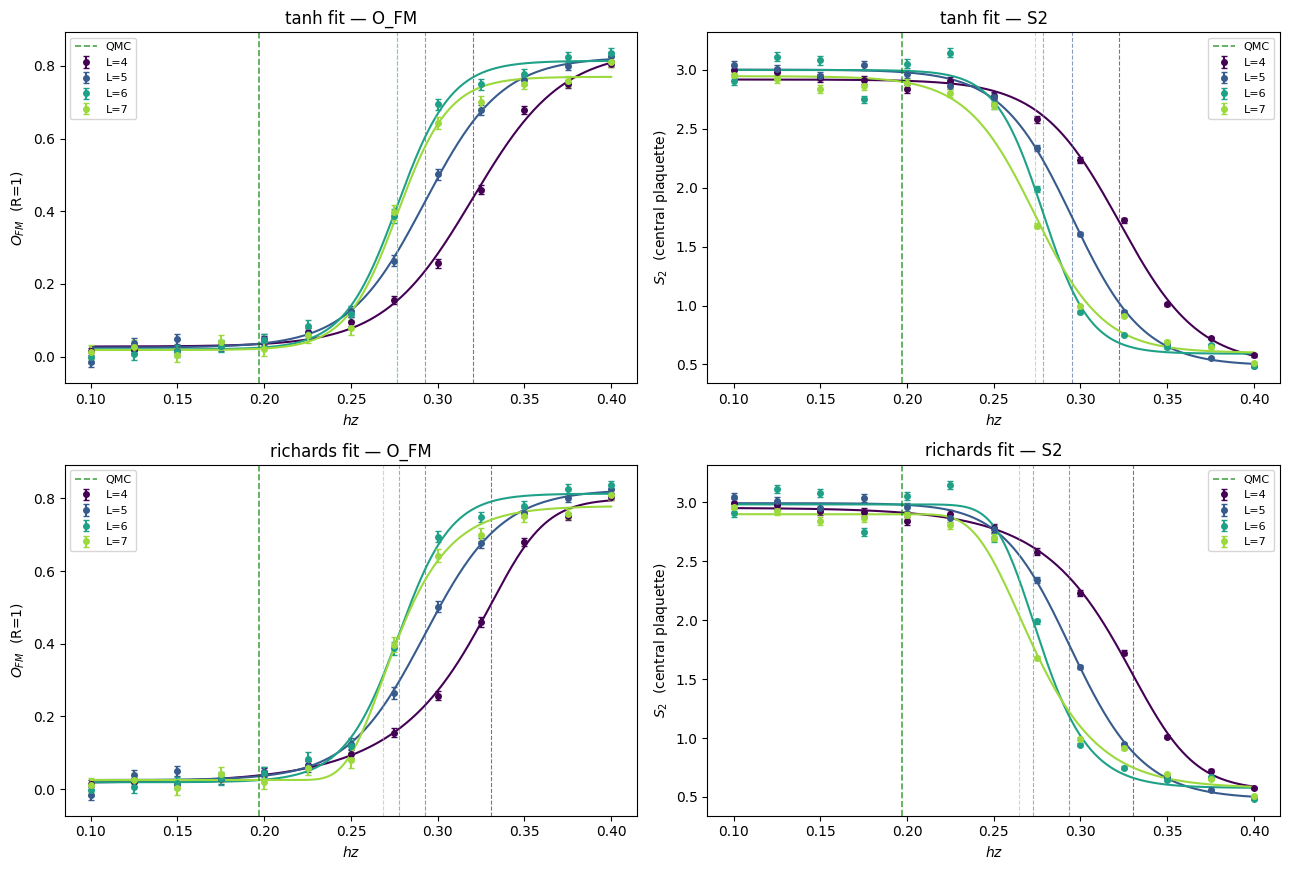

In [16]:
# ====================== 5 · PER-L FITS ======================
FITS = {}   # FITS[obs][form][L] = fit dict
for obs in ("O_FM", "S2"):
    FITS[obs] = {}
    for form in FORMS:
        FITS[obs][form] = {}
        for L in sorted(DATA[obs]):
            h, y, ye = points(obs, L, windowed=True)
            FITS[obs][form][L] = fit_curve(h, y, ye, form)

fig, ax = plt.subplots(len(FORMS), 2, figsize=(13, 4.4*len(FORMS)), squeeze=False)
for i, form in enumerate(FORMS):
    for j, obs in enumerate(("O_FM", "S2")):
        Ls = sorted(DATA[obs]); colors = plt.cm.viridis(np.linspace(0, 0.85, len(Ls)))
        print(f"\n[{obs} / {form}]  {'L':>2} {'h_c':>8} {'chi2/dof':>9} {'width':>8}"
              + ("  nu" if form == "richards" else ""))
        for L, c in zip(Ls, colors):
            fit = FITS[obs][form][L]; h, y, ye = points(obs, L, windowed=True)
            hh = np.linspace(h.min(), h.max(), 400)
            ax[i, j].errorbar(h, y, yerr=ye, fmt="o", ms=4, capsize=2, color=c, label=f"L={L}")
            ax[i, j].plot(hh, MODELS[form](hh, *fit["popt"]), "-", color=c)
            ax[i, j].axvline(fit["h_c"], ls="--", color=c, lw=0.8, alpha=0.6)
            extra = f"  {fit['popt'][4]:.2f}" if form == "richards" else ""
            w = abs(fit["popt"][3])
            print(f"    {L:>2} {fit['h_c']:>8.4f} {fit['chi2dof']:>9.1f} {w:>8.4f}{extra}")
        ax[i, j].axvline(H_C_QMC, ls="--", color="green", lw=1.2, alpha=0.7, label="QMC")
        ax[i, j].set(xlabel=f"${FIELD}$", ylabel=LABEL[obs],
                     title=f"{form} fit — {obs}"); ax[i, j].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6 · Honest errors — PDG scale-factor inflation

The quoted per-point $\sigma_i$ capture only Monte-Carlo sampling variance of a *fixed*
trained network. The dominant scatter at $L=6,7$ is **seed-to-seed NQS training variance**
(each $(h,L)$ is an independently optimized state), which the data itself exposes as
$\chi^2/\nu\gg1$. Following the PDG prescription for mutually inconsistent measurements:

1. fit the smooth model with the quoted errors → $\chi^2/\nu$;
2. inflate: $s=\max(1,\sqrt{\chi^2/\nu})$, $\;\sigma_i\to s\,\sigma_i$;
3. bootstrap $h_c(L)$ with the **inflated** errors, relocating the inflection each resample.

The naive (un-inflated) bootstrap error is reported alongside as the "fictional" comparison.
Treat the inflated error as a **floor**, not the truth (training bias can be coherent).

In [17]:
# ====================== 6 · HONEST ERRORS (scale-factor + bootstrap) ======================
def bootstrap_hc(obs, form, L, escale, B):
    h, y, ye = points(obs, L, windowed=True)
    e = ye*escale
    p0, bnds = _p0_bounds(form, h, y)
    lo, hi = h.min()-0.05, h.max()+0.05
    out = []
    for _ in range(B):
        yb = y + rng.normal(0, e)
        try:
            pb, _ = curve_fit(MODELS[form], h, yb, p0=p0, bounds=bnds,
                              sigma=e, absolute_sigma=True, maxfev=80000)
            hc = inflection(form, pb)
            if lo < hc < hi:
                out.append(hc)
        except Exception:
            pass
    return np.array(out)

HC = {}   # HC[obs][form][L] = dict(h_c, s, chi2dof, err_naive, err_honest)
for obs in ("O_FM", "S2"):
    HC[obs] = {}
    for form in FORMS:
        HC[obs][form] = {}
        print(f"\n[{obs} / {form}]  {'L':>2} {'h_c':>8} {'chi2/dof':>9} {'s':>5} "
              f"{'err_naive':>10} {'err_honest':>11}")
        for L in sorted(DATA[obs]):
            fit = FITS[obs][form][L]
            s = max(1.0, np.sqrt(fit["chi2dof"]))
            en = bootstrap_hc(obs, form, L, 1.0, N_BOOT)
            eh = bootstrap_hc(obs, form, L, s,   N_BOOT)
            HC[obs][form][L] = dict(
                h_c=fit["h_c"], s=s, chi2dof=fit["chi2dof"],
                err_naive=float(en.std()) if len(en) else np.nan,
                err_honest=float(eh.std()) if len(eh) else np.nan)
            r = HC[obs][form][L]
            print(f"    {L:>2} {r['h_c']:>8.4f} {r['chi2dof']:>9.1f} {r['s']:>5.1f} "
                  f"{r['err_naive']:>10.4f} {r['err_honest']:>11.4f}")


[O_FM / tanh]   L      h_c  chi2/dof     s  err_naive  err_honest
     4   0.3202       2.9   1.7     0.0016      0.0025
     5   0.2925       1.7   1.3     0.0013      0.0018
     6   0.2768       2.9   1.7     0.0013      0.0021
     7   0.2768       2.9   1.7     0.0014      0.0023

[O_FM / richards]   L      h_c  chi2/dof     s  err_naive  err_honest
     4   0.3308       1.2   1.1     0.0028      0.0031
     5   0.2924       1.9   1.4     0.0038      0.0055


/var/folders/qq/fj8fj1hj4q98rqt9p4pjwdn40000gn/T/ipykernel_32894/2128232949.py:4: RuntimeWarning: overflow encountered in power
  return A + (K - A) / (1.0 + np.exp(z))**nu


     6   0.2776       3.3   1.8     0.0049      0.0077
     7   0.2685       2.2   1.5     0.0018      0.0031

[S2 / tanh]   L      h_c  chi2/dof     s  err_naive  err_honest
     4   0.3224       5.6   2.4     0.0007      0.0015
     5   0.2952       2.6   1.6     0.0006      0.0009
     6   0.2782      49.0   7.0     0.0004      0.0033
     7   0.2737      54.3   7.4     0.0005      0.0039

[S2 / richards]   L      h_c  chi2/dof     s  err_naive  err_honest
     4   0.3300       3.9   2.0     0.0017      0.0032
     5   0.2936       2.8   1.7     0.0016      0.0030
     6   0.2728      52.1   7.2     0.0013      0.0086
     7   0.2648      43.5   6.6     0.0006      0.0046


## 7 · Finite-size extrapolation

$h_c(L) = h_c^{\infty} + b\,(1/L)^x$, weighted by the honest $\sigma[h_c(L)]$ from §6.
`FSS_FIX_X` pins $x$ (e.g. $1.59=1/\nu$ for the 3D Ising / toric-code universality class);
`None` fits $x$ freely (ill-constrained with 4 points — reported for completeness). The
`X_BATTERY` sweep gives the **systematic** spread from the exponent choice, the one
systematic that survives error inflation.

[O_FM / tanh]  h_c(inf) = 0.2679 ± 0.0058 (stat) ± 0.0199 (syst, exponent)   x free=3.64±0.91   offset vs QMC +0.0709
[S2 / tanh]  h_c(inf) = 0.2502 ± 0.0161 (stat) ± 0.0263 (syst, exponent)   x free=2.13±0.67   offset vs QMC +0.0532
[O_FM / richards]  h_c(inf) = 0.2561 ± 0.0141 (stat) ± 0.0268 (syst, exponent)   x free=3.19±1.46   offset vs QMC +0.0591
[S2 / richards]  h_c(inf) = 0.2406 ± 0.0219 (stat) ± 0.0302 (syst, exponent)   x free=2.36±0.97   offset vs QMC +0.0436


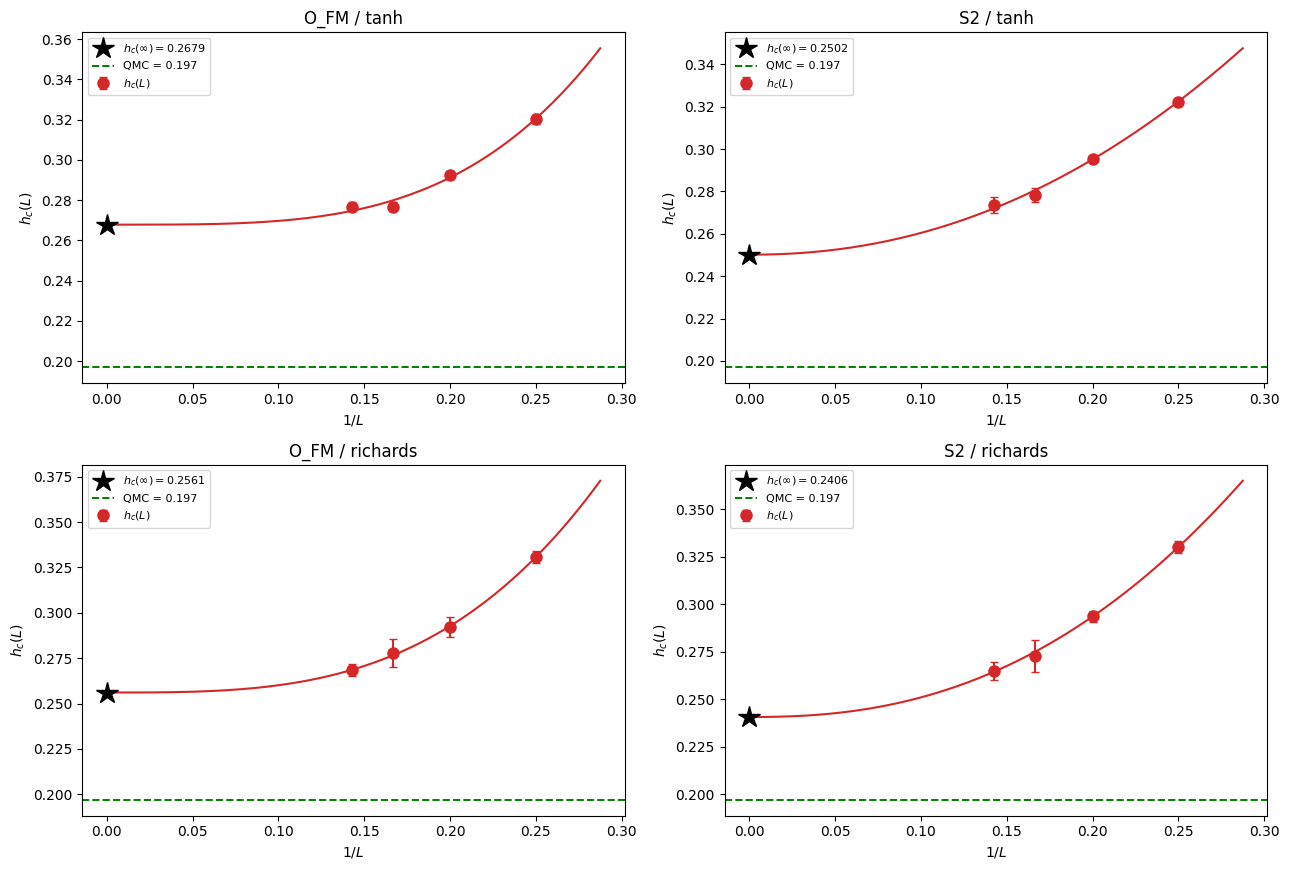


--- summary: h_c(inf) ---
   O_FM / tanh     : 0.2679 ± 0.0058
     S2 / tanh     : 0.2502 ± 0.0161
   O_FM / richards : 0.2561 ± 0.0141
     S2 / richards : 0.2406 ± 0.0219


In [18]:
# ====================== 7 · FINITE-SIZE EXTRAPOLATION ======================
def fss(hc_by_L, use_L=None, fix_x=None):
    use_L = sorted(hc_by_L) if use_L is None else sorted(int(x) for x in use_L)
    L = np.array(use_L, float)
    y = np.array([hc_by_L[k]["h_c"]       for k in use_L])
    e = np.array([hc_by_L[k]["err_honest"] for k in use_L])
    w_ok = np.all(np.isfinite(e)) and np.all(e > 0)
    kw = dict(sigma=e, absolute_sigma=True) if w_ok else {}
    if fix_x is None:
        f = lambda LL, h0, b, x: h0 + b*(1.0/LL)**x
        p, c = curve_fit(f, L, y, p0=[y.min(), 0.3, 1.5],
                         bounds=([-np.inf, -np.inf, 0.1], [np.inf, np.inf, 6.0]),
                         maxfev=80000, **kw)
        h0, b, x = map(float, p); xerr = float(np.sqrt(abs(c[2, 2])))
    else:
        f = lambda LL, h0, b: h0 + b*(1.0/LL)**fix_x
        p, c = curve_fit(f, L, y, p0=[y.min(), 0.3], maxfev=80000, **kw)
        h0, b, x, xerr = float(p[0]), float(p[1]), float(fix_x), 0.0
    return dict(h0=h0, h0_err=float(np.sqrt(abs(c[0, 0]))), b=b, x=x, xerr=xerr,
                L=L, y=y, e=e, weighted=w_ok)

RESULT = {}
fig, ax = plt.subplots(len(FORMS), 2, figsize=(13, 4.4*len(FORMS)), squeeze=False)
for i, form in enumerate(FORMS):
    for j, obs in enumerate(("O_FM", "S2")):
        F = fss(HC[obs][form], use_L=FSS_LS, fix_x=FSS_FIX_X)
        RESULT[(obs, form)] = F
        # systematic spread over the exponent battery
        batt = []
        for xx in X_BATTERY:
            try: batt.append(fss(HC[obs][form], use_L=FSS_LS, fix_x=xx)["h0"])
            except Exception: pass
        syst = 0.5*(max(batt)-min(batt)) if batt else np.nan
        xtag = f"x={F['x']:.2f}" if FSS_FIX_X is not None else f"x free={F['x']:.2f}±{F['xerr']:.2f}"
        print(f"[{obs} / {form}]  h_c(inf) = {F['h0']:.4f} ± {F['h0_err']:.4f} (stat) "
              f"± {syst:.4f} (syst, exponent)   {xtag}   "
              f"offset vs QMC {F['h0']-H_C_QMC:+.4f}")

        LL = np.linspace(F["L"].min()*0.9, F["L"].max()*1.5, 200); invL = 1.0/F["L"]
        grid = np.linspace(0, invL.max()*1.15, 200)
        a = ax[i, j]
        a.errorbar(invL, F["y"], yerr=(F["e"] if F["weighted"] else None),
                   fmt="o", ms=8, color="C3", capsize=3, label="$h_c(L)$")
        a.plot(grid, F["h0"] + F["b"]*grid**F["x"], "-", color="C3")
        a.plot(0, F["h0"], "*", ms=16, color="k", label=fr"$h_c(\infty)={F['h0']:.4f}$")
        a.axhline(H_C_QMC, ls="--", color="green", lw=1.4, label=f"QMC = {H_C_QMC}")
        a.set(xlabel="$1/L$", ylabel=f"$h_c(L)$", title=f"{obs} / {form}"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("\n--- summary: h_c(inf) ---")
for (obs, form), F in RESULT.items():
    print(f"  {obs:>5} / {form:<9}: {F['h0']:.4f} ± {F['h0_err']:.4f}")

## Next steps

Four independent estimates of $h_z^c$ are now in `RESULT[(obs, form)]` (2 observables ×
2 fit forms), each with a statistical (inflated-bootstrap) and a systematic (exponent-choice)
error. Combining them — e.g. an error-weighted mean, or treating the $O_{FM}$/$S_2$ spread as
a further systematic — is the next decision; the honest errors here are the inputs to that.